In [ ]:
!pip install fredapi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import time

plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 500)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]

from fredapi import Fred

fred_key = 'Secret_key'

In [2]:
fred = Fred(api_key=fred_key)

In [3]:
sp_search = fred.search('S&P', order_by='popularity')

In [ ]:
sp_search.head()

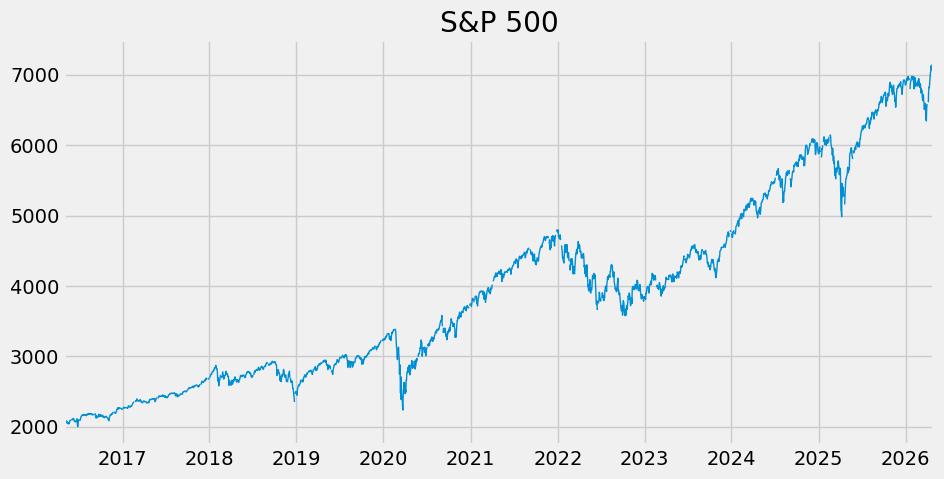

In [20]:
sp500 = fred.get_series(series_id='SP500')
sp500.plot(figsize=(10, 5), title='S&P 500', lw=1)
plt.show()

In [21]:
unemp_df = fred.search("unemployment rate state", filter=("frequency","Monthly"))
unemp_df = unemp_df[(unemp_df["seasonal_adjustment"] == "Seasonally Adjusted") & (unemp_df["units"] == "Percent") ]
unemp_df = unemp_df.loc[unemp_df['title'].str.contains('Unemployment Rate')]

In [23]:
cols_to_drop = []
for i in unemp_df.index:
    # print("i",i)
    if len(i) > 4:
        cols_to_drop.append(i)
unemp_df
# print("cols_to_drop", len(cols_to_drop))
unemp_df = unemp_df.drop(index = cols_to_drop, axis=0)

In [24]:
unemp_df.head()

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
CAUR,CAUR,2026-05-02,2026-05-02,Unemployment Rate in California,1976-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-04-23 15:59:32-05:00,66,None
TXUR,TXUR,2026-05-02,2026-05-02,Unemployment Rate in Texas,1976-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-04-23 15:58:51-05:00,59,None
NYUR,NYUR,2026-05-02,2026-05-02,Unemployment Rate in New York,1976-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-04-23 15:58:52-05:00,58,None
FLUR,FLUR,2026-05-02,2026-05-02,Unemployment Rate in Florida,1976-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-04-23 15:59:28-05:00,55,None
ALUR,ALUR,2026-05-02,2026-05-02,Unemployment Rate in Alabama,1976-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-04-23 15:59:34-05:00,49,None


In [26]:
unemp_df.drop(columns="notes", axis=1 , inplace=True)

In [27]:
all_results = []

for myid in unemp_df.index:
    results = fred.get_series(myid)
    results = results.to_frame(myid)
    all_results.append(results)
    time.sleep(0.1)

unemp_results = pd.concat(all_results,axis=1)
    

In [29]:
unemp_results

,CAUR,TXUR,NYUR,FLUR,ALUR,ILUR,GAUR,MIUR,VAUR,OHUR,PAUR,KYUR,LAUR,MSUR,NJUR,MAUR,MOUR,WIUR,NCUR,COUR,MNUR,WAUR,DCUR,ORUR,AZUR,TNUR,NVUR,MDUR,INUR,SCUR,UTUR,OKUR,WVUR,ARUR,IAUR,NMUR,DEUR,PRUR,CTUR,AKUR,HIUR,NDUR,RIUR,IDUR,KSUR,MEUR
1976-01-01,9.2,5.8,10.3,9.6,6.7,6.6,8.4,9.9,6.0,8.1,8.1,5.6,6.3,6.6,10.2,10.6,6.0,5.8,6.5,5.8,5.9,8.5,8.8,9.5,10.2,6.0,9.2,6.5,6.6,7.3,5.8,5.8,7.4,7.3,4.4,8.6,8.0,19.6,9.7,7.1,9.6,3.5,7.7,5.6,4.2,8.7
1976-02-01,9.2,5.8,10.3,9.7,6.6,6.6,8.4,9.9,6.0,8.1,8.1,5.6,6.3,6.6,10.2,10.6,6.0,5.8,6.5,5.8,5.9,8.5,8.8,9.5,10.2,6.0,9.2,6.5,6.6,7.3,5.9,5.8,7.4,7.3,4.4,8.6,8.0,19.5,9.7,7.1,9.6,3.5,7.7,5.6,4.2,8.7
1976-03-01,9.1,5.9,10.2,9.6,6.6,6.6,8.3,9.9,6.0,8.1,8.1,5.6,6.3,6.6,10.2,10.6,6.0,5.8,6.5,5.7,5.8,8.5,8.7,9.4,10.2,6.0,9.2,6.5,6.5,7.3,5.8,5.8,7.4,7.3,4.4,8.6,8.0,19.3,9.7,7.0,9.6,3.5,7.7,5.6,4.2,8.6
1976-04-01,9.0,5.9,10.2,9.5,6.5,6.6,8.2,9.8,5.9,7.9,8.1,5.6,6.4,6.4,10.3,10.4,6.0,5.7,6.3,5.6,5.7,8.5,8.6,9.3,10.0,6.0,9.0,6.5,6.3,7.1,5.8,5.7,7.4,7.2,4.3,8.6,8.2,19.0,9.6,7.0,9.4,3.6,7.7,5.6,4.2,8.6
1976-05-01,8.9,6.0,10.2,9.3,6.4,6.6,8.1,9.6,5.8,7.8,8.1,5.5,6.5,6.3,10.3,10.1,6.0,5.6,6.1,5.6,5.6,8.5,8.5,9.1,9.8,5.9,8.8,6.6,6.0,7.0,5.7,5.7,7.4,7.1,4.2,8.6,8.4,18.9,9.4,7.0,9.3,3.6,7.7,5.6,4.2,8.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,5.5,4.3,4.6,4.3,2.7,4.7,3.5,5.0,3.6,4.3,4.4,4.4,4.2,3.7,5.4,4.7,3.9,3.2,3.8,3.8,4.2,4.9,6.7,5.3,4.4,3.6,5.2,4.3,3.5,4.8,3.7,3.7,4.6,4.3,3.4,4.3,5.3,5.7,4.3,4.8,2.2,2.6,4.4,3.6,3.8,3.3
2025-12-01,5.5,4.3,4.6,4.3,2.7,4.7,3.5,5.0,3.6,4.4,4.4,4.4,4.2,3.7,5.4,4.7,3.9,3.2,3.8,3.8,4.2,4.9,6.7,5.3,4.4,3.6,5.2,4.2,3.5,4.8,3.7,3.7,4.6,4.3,3.4,4.3,5.3,5.7,4.3,4.8,2.2,2.6,4.4,3.6,3.8,3.3
2026-01-01,5.4,4.3,4.6,4.5,2.7,4.9,3.5,5.0,3.7,4.3,4.3,4.3,4.3,3.6,5.2,4.7,3.9,3.3,3.8,3.9,4.4,5.0,6.7,5.2,4.5,3.5,5.3,4.3,3.4,4.9,3.8,3.9,4.6,4.4,3.4,4.5,5.4,5.7,4.5,4.8,2.2,2.6,4.5,3.7,3.9,3.3


In [30]:
unemp_results = pd.concat(all_results, axis=1)

In [31]:
unemp_results

,CAUR,TXUR,NYUR,FLUR,ALUR,ILUR,GAUR,MIUR,VAUR,OHUR,PAUR,KYUR,LAUR,MSUR,NJUR,MAUR,MOUR,WIUR,NCUR,COUR,MNUR,WAUR,DCUR,ORUR,AZUR,TNUR,NVUR,MDUR,INUR,SCUR,UTUR,OKUR,WVUR,ARUR,IAUR,NMUR,DEUR,PRUR,CTUR,AKUR,HIUR,NDUR,RIUR,IDUR,KSUR,MEUR
1976-01-01,9.2,5.8,10.3,9.6,6.7,6.6,8.4,9.9,6.0,8.1,8.1,5.6,6.3,6.6,10.2,10.6,6.0,5.8,6.5,5.8,5.9,8.5,8.8,9.5,10.2,6.0,9.2,6.5,6.6,7.3,5.8,5.8,7.4,7.3,4.4,8.6,8.0,19.6,9.7,7.1,9.6,3.5,7.7,5.6,4.2,8.7
1976-02-01,9.2,5.8,10.3,9.7,6.6,6.6,8.4,9.9,6.0,8.1,8.1,5.6,6.3,6.6,10.2,10.6,6.0,5.8,6.5,5.8,5.9,8.5,8.8,9.5,10.2,6.0,9.2,6.5,6.6,7.3,5.9,5.8,7.4,7.3,4.4,8.6,8.0,19.5,9.7,7.1,9.6,3.5,7.7,5.6,4.2,8.7
1976-03-01,9.1,5.9,10.2,9.6,6.6,6.6,8.3,9.9,6.0,8.1,8.1,5.6,6.3,6.6,10.2,10.6,6.0,5.8,6.5,5.7,5.8,8.5,8.7,9.4,10.2,6.0,9.2,6.5,6.5,7.3,5.8,5.8,7.4,7.3,4.4,8.6,8.0,19.3,9.7,7.0,9.6,3.5,7.7,5.6,4.2,8.6
1976-04-01,9.0,5.9,10.2,9.5,6.5,6.6,8.2,9.8,5.9,7.9,8.1,5.6,6.4,6.4,10.3,10.4,6.0,5.7,6.3,5.6,5.7,8.5,8.6,9.3,10.0,6.0,9.0,6.5,6.3,7.1,5.8,5.7,7.4,7.2,4.3,8.6,8.2,19.0,9.6,7.0,9.4,3.6,7.7,5.6,4.2,8.6
1976-05-01,8.9,6.0,10.2,9.3,6.4,6.6,8.1,9.6,5.8,7.8,8.1,5.5,6.5,6.3,10.3,10.1,6.0,5.6,6.1,5.6,5.6,8.5,8.5,9.1,9.8,5.9,8.8,6.6,6.0,7.0,5.7,5.7,7.4,7.1,4.2,8.6,8.4,18.9,9.4,7.0,9.3,3.6,7.7,5.6,4.2,8.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,5.5,4.3,4.6,4.3,2.7,4.7,3.5,5.0,3.6,4.3,4.4,4.4,4.2,3.7,5.4,4.7,3.9,3.2,3.8,3.8,4.2,4.9,6.7,5.3,4.4,3.6,5.2,4.3,3.5,4.8,3.7,3.7,4.6,4.3,3.4,4.3,5.3,5.7,4.3,4.8,2.2,2.6,4.4,3.6,3.8,3.3
2025-12-01,5.5,4.3,4.6,4.3,2.7,4.7,3.5,5.0,3.6,4.4,4.4,4.4,4.2,3.7,5.4,4.7,3.9,3.2,3.8,3.8,4.2,4.9,6.7,5.3,4.4,3.6,5.2,4.2,3.5,4.8,3.7,3.7,4.6,4.3,3.4,4.3,5.3,5.7,4.3,4.8,2.2,2.6,4.4,3.6,3.8,3.3
2026-01-01,5.4,4.3,4.6,4.5,2.7,4.9,3.5,5.0,3.7,4.3,4.3,4.3,4.3,3.6,5.2,4.7,3.9,3.3,3.8,3.9,4.4,5.0,6.7,5.2,4.5,3.5,5.3,4.3,3.4,4.9,3.8,3.9,4.6,4.4,3.4,4.5,5.4,5.7,4.5,4.8,2.2,2.6,4.5,3.7,3.9,3.3


In [ ]:
uemp_results

In [33]:
uemp_states = unemp_results.copy()  #.drop('UNRATE', axis=1)
uemp_states = uemp_states.dropna()
id_to_state = unemp_df['title'].str.replace('Unemployment Rate in ','').to_dict()
uemp_states.columns = [id_to_state[c] for c in uemp_states.columns]

In [34]:
uemp_states

,California,Texas,New York,Florida,Alabama,Illinois,Georgia,Michigan,Virginia,Ohio,Pennsylvania,Kentucky,Louisiana,Mississippi,New Jersey,Massachusetts,Missouri,Wisconsin,North Carolina,Colorado,Minnesota,Washington,the District of Columbia,Oregon,Arizona,Tennessee,Nevada,Maryland,Indiana,South Carolina,Utah,Oklahoma,West Virginia,Arkansas,Iowa,New Mexico,Delaware,Puerto Rico,Connecticut,Alaska,Hawaii,North Dakota,Rhode Island,Idaho,Kansas,Maine
1976-01-01,9.2,5.8,10.3,9.6,6.7,6.6,8.4,9.9,6.0,8.1,8.1,5.6,6.3,6.6,10.2,10.6,6.0,5.8,6.5,5.8,5.9,8.5,8.8,9.5,10.2,6.0,9.2,6.5,6.6,7.3,5.8,5.8,7.4,7.3,4.4,8.6,8.0,19.6,9.7,7.1,9.6,3.5,7.7,5.6,4.2,8.7
1976-02-01,9.2,5.8,10.3,9.7,6.6,6.6,8.4,9.9,6.0,8.1,8.1,5.6,6.3,6.6,10.2,10.6,6.0,5.8,6.5,5.8,5.9,8.5,8.8,9.5,10.2,6.0,9.2,6.5,6.6,7.3,5.9,5.8,7.4,7.3,4.4,8.6,8.0,19.5,9.7,7.1,9.6,3.5,7.7,5.6,4.2,8.7
1976-03-01,9.1,5.9,10.2,9.6,6.6,6.6,8.3,9.9,6.0,8.1,8.1,5.6,6.3,6.6,10.2,10.6,6.0,5.8,6.5,5.7,5.8,8.5,8.7,9.4,10.2,6.0,9.2,6.5,6.5,7.3,5.8,5.8,7.4,7.3,4.4,8.6,8.0,19.3,9.7,7.0,9.6,3.5,7.7,5.6,4.2,8.6
1976-04-01,9.0,5.9,10.2,9.5,6.5,6.6,8.2,9.8,5.9,7.9,8.1,5.6,6.4,6.4,10.3,10.4,6.0,5.7,6.3,5.6,5.7,8.5,8.6,9.3,10.0,6.0,9.0,6.5,6.3,7.1,5.8,5.7,7.4,7.2,4.3,8.6,8.2,19.0,9.6,7.0,9.4,3.6,7.7,5.6,4.2,8.6
1976-05-01,8.9,6.0,10.2,9.3,6.4,6.6,8.1,9.6,5.8,7.8,8.1,5.5,6.5,6.3,10.3,10.1,6.0,5.6,6.1,5.6,5.6,8.5,8.5,9.1,9.8,5.9,8.8,6.6,6.0,7.0,5.7,5.7,7.4,7.1,4.2,8.6,8.4,18.9,9.4,7.0,9.3,3.6,7.7,5.6,4.2,8.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-01,5.5,4.3,4.6,4.2,2.8,4.5,3.4,4.9,3.4,4.3,4.4,4.5,4.2,3.7,5.5,4.6,3.9,3.1,3.9,3.8,4.1,4.7,6.6,5.3,4.4,3.5,5.2,4.3,3.7,4.7,3.6,3.6,4.5,4.2,3.4,4.2,5.2,5.7,4.2,4.7,2.1,2.6,4.3,3.6,3.8,3.3
2025-11-01,5.5,4.3,4.6,4.3,2.7,4.7,3.5,5.0,3.6,4.3,4.4,4.4,4.2,3.7,5.4,4.7,3.9,3.2,3.8,3.8,4.2,4.9,6.7,5.3,4.4,3.6,5.2,4.3,3.5,4.8,3.7,3.7,4.6,4.3,3.4,4.3,5.3,5.7,4.3,4.8,2.2,2.6,4.4,3.6,3.8,3.3
2025-12-01,5.5,4.3,4.6,4.3,2.7,4.7,3.5,5.0,3.6,4.4,4.4,4.4,4.2,3.7,5.4,4.7,3.9,3.2,3.8,3.8,4.2,4.9,6.7,5.3,4.4,3.6,5.2,4.2,3.5,4.8,3.7,3.7,4.6,4.3,3.4,4.3,5.3,5.7,4.3,4.8,2.2,2.6,4.4,3.6,3.8,3.3
2026-01-01,5.4,4.3,4.6,4.5,2.7,4.9,3.5,5.0,3.7,4.3,4.3,4.3,4.3,3.6,5.2,4.7,3.9,3.3,3.8,3.9,4.4,5.0,6.7,5.2,4.5,3.5,5.3,4.3,3.4,4.9,3.8,3.9,4.6,4.4,3.4,4.5,5.4,5.7,4.5,4.8,2.2,2.6,4.5,3.7,3.9,3.3


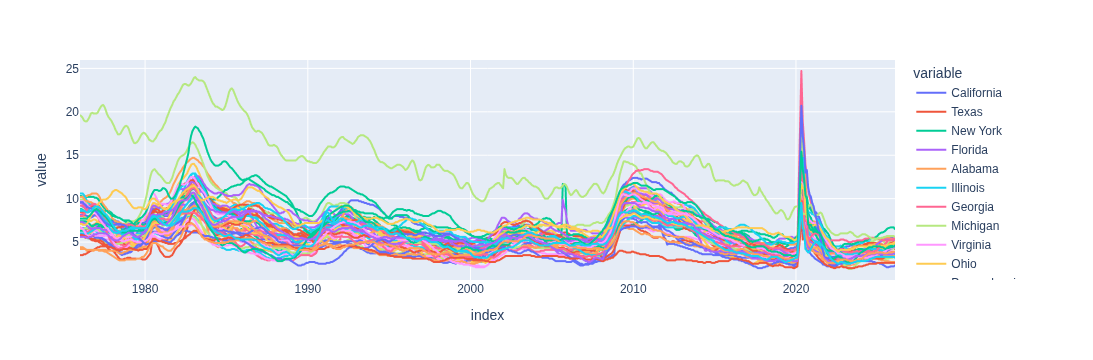

In [35]:
px.line(uemp_states)

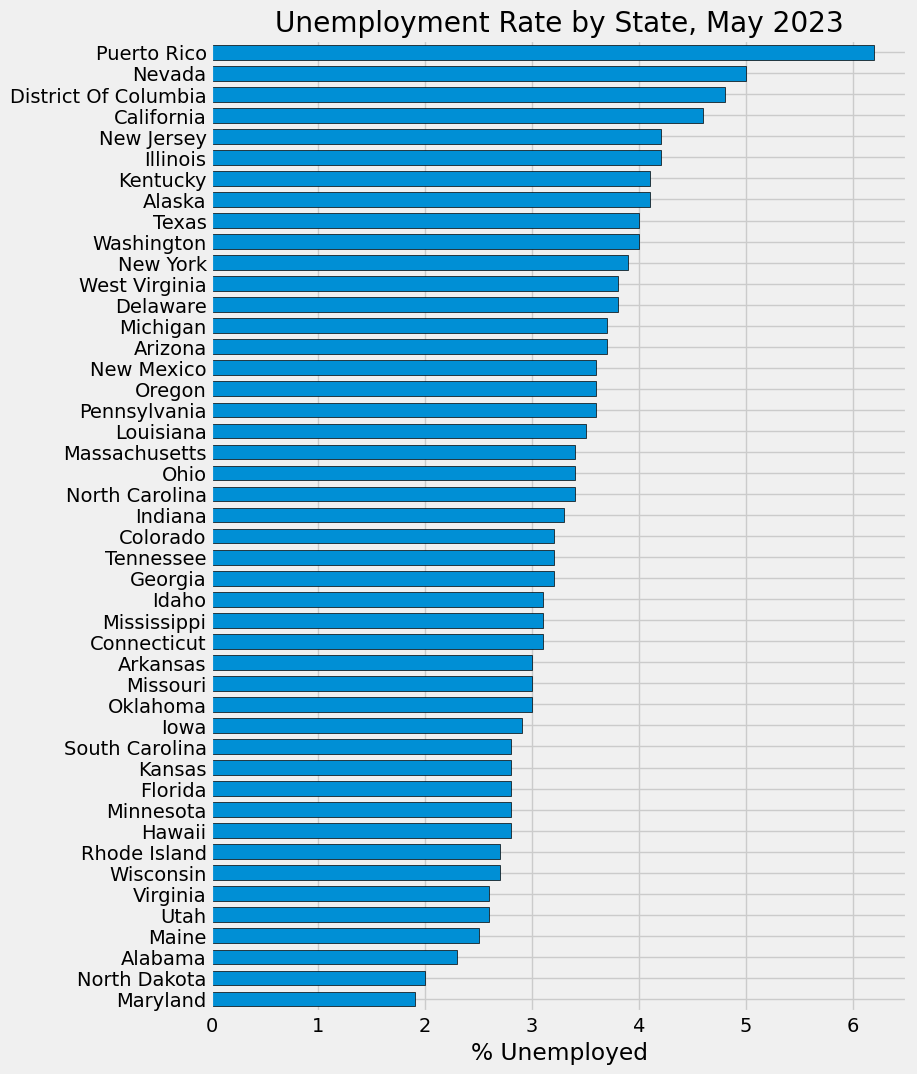

In [42]:
ax = uemp_states.loc[uemp_states.index == '2023-05-01'].T \
    .sort_values('2023-05-01') \
    .plot(kind='barh', figsize=(8, 12), width=0.7, edgecolor='black',
          title='Unemployment Rate by State, May 2023')
ax.legend().remove()
ax.set_xlabel('% Unemployed')
plt.show()

In [4]:

part_df = fred.search('participation rate state', filter=('frequency','Monthly'))
part_df = part_df.query('seasonal_adjustment == "Seasonally Adjusted" and units == "Percent"')

In [5]:
part_id_to_state = part_df['title'].str.replace('Labor Force Participation Rate for ','').to_dict()

In [6]:
part_id_to_state

{'CIVPART': 'Labor Force Participation Rate',
 'LNS11300060': 'Labor Force Participation Rate - 25-54 Yrs.',
 'LNS11300002': 'Labor Force Participation Rate - Women',
 'LNS11300001': 'Labor Force Participation Rate - Men',
 'LNS11324230': 'Labor Force Participation Rate - 55 Yrs. & over',
 'LRAC25MAUSM156S': 'Infra-Annual Labor Statistics: Labor Force Participation Rate Male: From 25 to 54 Years for United States',
 'LNS11300012': 'Labor Force Participation Rate - 16-19 Yrs.',
 'LRAC25FEUSM156S': 'Infra-Annual Labor Statistics: Labor Force Participation Rate Female: From 25 to 54 Years for United States',
 'LBSSA01': 'Alabama',
 'LNS11300036': 'Labor Force Participation Rate - 20-24 Yrs.',
 'LBSSA13': 'Georgia',
 'LBSSA28': 'Mississippi',
 'LBSSA22': 'Louisiana',
 'LNS11300006': 'Labor Force Participation Rate - Black or African American',
 'LNS11327662': "Labor Force Participation Rate - Bachelor's Degree and Higher, 25 Yrs. & over",
 'LBSSA06': 'California',
 'LNS11300028': 'Labor Fo

In [11]:
cols_to_drop = []
for i in part_df.index:
    # print("i",i)
    if len(i) > 7:
        cols_to_drop.append(i)

# print("cols_to_drop", cols_to_drop)
part_df.head()
part_df = part_df.drop(index = cols_to_drop, axis=0)

In [12]:
all_results = []

for myId in part_df.index:
    # print(state)
    result = fred.get_series(myId)
    result = result.to_frame(name=myId)
    all_results.append(result)
    time.sleep(0.2)
    

In [15]:
part_states = pd.concat(all_results, axis=1)
part_states.columns = [part_id_to_state[c] for c in part_states.columns]

In [16]:
part_states

,Labor Force Participation Rate,Alabama,Georgia,Mississippi,Louisiana,California,Minnesota,Michigan,Florida,Wisconsin,Illinois,Virginia,Pennsylvania,New York,Texas,Ohio,North Carolina,Massachusetts,West Virginia,Colorado,New Mexico,Tennessee,Washington,Arizona,Oklahoma,New Jersey,Utah,Maryland,South Carolina,Kentucky,Maine,Connecticut,Oregon,Iowa,Arkansas,Indiana,Nevada,Rhode Island,New Hampshire,Missouri,Kansas,Idaho,Delaware,Hawaii,Alaska,Wyoming,Nebraska,Montana,District Of Columbia,North Dakota,South Dakota,Vermont
1948-01-01,58.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-02-01,58.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-03-01,58.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-04-01,59.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-05-01,58.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-01,62.5,57.7,60.8,55.7,58.5,62.6,68.3,60.7,57.6,64.2,63.9,63.9,61.8,61.6,64.8,62.3,59.3,66.3,54.6,66.9,57.6,60.6,62.7,62.1,62.9,63.7,67.7,64.3,58.6,58.3,59.8,63.9,63.0,67.9,59.0,63.6,63.4,63.8,65.3,63.6,68.0,63.0,59.7,60.7,65.9,61.3,70.2,62.3,71.4,69.9,68.2,63.7
2025-12-01,62.4,57.6,60.8,55.7,58.5,62.6,68.3,60.7,57.6,64.2,63.9,63.9,61.8,61.6,64.7,62.3,59.3,66.3,54.6,66.9,57.6,60.6,62.6,62.0,62.9,63.7,67.7,64.2,58.5,58.3,59.8,63.9,63.0,67.9,59.0,63.6,63.4,63.8,65.3,63.6,68.0,62.9,59.7,60.7,65.9,61.3,70.2,62.3,71.5,69.9,68.1,63.7
2026-01-01,62.1,57.6,60.8,55.6,58.6,62.5,68.2,60.6,57.6,64.3,63.9,63.8,61.9,61.7,64.7,62.2,59.2,66.2,54.5,66.8,57.6,60.5,62.6,62.0,62.8,63.6,67.5,64.1,58.7,58.1,59.7,63.8,62.9,67.9,59.1,63.5,63.6,63.7,65.3,63.6,67.9,62.8,59.5,60.7,66.1,61.2,70.1,62.3,71.3,70.0,68.0,63.5
2026-02-01,62.0,57.5,60.8,55.6,58.7,62.4,67.9,60.5,57.7,64.4,64.0,63.7,61.9,61.8,64.6,62.2,59.1,66.0,54.5,66.6,57.5,60.3,62.6,61.7,62.7,63.6,67.4,64.0,58.9,57.9,59.6,63.7,62.8,67.8,59.2,63.4,63.7,63.4,65.3,63.6,67.8,62.7,59.3,60.7,66.2,61.2,70.1,62.2,71.1,70.1,67.8,63.2


In [17]:
part_states.dropna(inplace=True)

In [39]:
uemp_states = uemp_states.rename(columns={'the District of Columbia':'District Of Columbia'})

In [18]:
part_states

,Labor Force Participation Rate,Alabama,Georgia,Mississippi,Louisiana,California,Minnesota,Michigan,Florida,Wisconsin,Illinois,Virginia,Pennsylvania,New York,Texas,Ohio,North Carolina,Massachusetts,West Virginia,Colorado,New Mexico,Tennessee,Washington,Arizona,Oklahoma,New Jersey,Utah,Maryland,South Carolina,Kentucky,Maine,Connecticut,Oregon,Iowa,Arkansas,Indiana,Nevada,Rhode Island,New Hampshire,Missouri,Kansas,Idaho,Delaware,Hawaii,Alaska,Wyoming,Nebraska,Montana,District Of Columbia,North Dakota,South Dakota,Vermont
1976-01-01,61.3,57.1,63.8,58.8,56.9,62.5,65.5,61.6,55.8,65.6,63.1,65.9,58.4,58.1,63.7,61.7,66.6,64.8,52.5,67.3,60.6,59.7,61.0,59.5,59.4,61.5,62.8,64.3,65.3,60.5,62.1,64.1,63.0,64.4,57.9,64.0,71.4,63.8,65.8,60.5,65.2,63.1,62.7,69.9,69.3,65.3,64.7,62.5,64.4,62.7,64.8,63.7
1976-02-01,61.3,56.9,63.6,58.6,56.7,62.4,65.4,61.5,55.6,65.5,63.0,65.7,58.3,58.0,63.5,61.6,66.4,64.7,52.4,67.1,60.4,59.5,60.8,59.2,59.3,61.4,62.6,64.1,65.2,60.3,61.9,64.0,62.8,64.3,57.8,63.9,70.8,63.7,65.6,60.4,65.1,62.9,62.6,69.7,68.6,65.0,64.6,62.4,64.5,62.5,64.7,63.5
1976-03-01,61.3,56.8,63.5,58.5,56.5,62.2,65.3,61.5,55.5,65.5,62.9,65.5,58.3,58.0,63.3,61.6,66.3,64.6,52.3,66.9,60.2,59.4,60.6,59.1,59.2,61.4,62.5,64.1,65.0,60.2,61.9,63.9,62.6,64.2,57.8,63.8,70.5,63.7,65.5,60.3,65.0,62.8,62.6,69.6,68.1,64.8,64.6,62.3,64.6,62.4,64.6,63.4
1976-04-01,61.6,56.8,63.6,58.5,56.5,62.2,65.3,61.6,55.4,65.5,62.9,65.4,58.3,58.0,63.4,61.6,66.3,64.6,52.3,66.7,60.1,59.3,60.7,59.1,59.1,61.5,62.5,64.1,64.9,60.2,61.8,64.1,62.5,64.1,57.7,63.8,70.5,63.7,65.6,60.4,65.1,62.8,62.5,69.4,68.2,65.0,64.6,62.1,64.6,62.5,64.6,63.6
1976-05-01,61.5,56.8,63.6,58.5,56.5,62.2,65.5,61.7,55.3,65.6,63.0,65.4,58.3,58.1,63.6,61.5,66.3,64.6,52.2,66.5,60.2,59.4,60.9,59.2,59.0,61.6,62.6,64.1,64.7,60.1,61.7,64.3,62.6,64.1,57.8,63.9,70.6,63.7,66.0,60.6,65.2,62.9,62.5,69.3,68.2,65.2,64.6,62.0,64.4,62.6,64.6,63.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-01,62.5,57.6,60.8,55.7,58.2,62.5,68.4,60.8,57.6,64.1,63.9,64.0,61.6,61.3,64.9,62.3,59.4,66.4,54.6,67.0,57.5,60.6,62.7,62.1,63.1,63.7,67.8,64.4,58.5,58.3,59.8,63.9,63.0,67.8,58.9,63.7,63.2,63.9,65.3,63.6,68.0,63.1,59.8,60.6,65.8,61.3,70.2,62.4,71.4,69.8,68.2,63.8
2025-11-01,62.5,57.7,60.8,55.7,58.5,62.6,68.3,60.7,57.6,64.2,63.9,63.9,61.8,61.6,64.8,62.3,59.3,66.3,54.6,66.9,57.6,60.6,62.7,62.1,62.9,63.7,67.7,64.3,58.6,58.3,59.8,63.9,63.0,67.9,59.0,63.6,63.4,63.8,65.3,63.6,68.0,63.0,59.7,60.7,65.9,61.3,70.2,62.3,71.4,69.9,68.2,63.7
2025-12-01,62.4,57.6,60.8,55.7,58.5,62.6,68.3,60.7,57.6,64.2,63.9,63.9,61.8,61.6,64.7,62.3,59.3,66.3,54.6,66.9,57.6,60.6,62.6,62.0,62.9,63.7,67.7,64.2,58.5,58.3,59.8,63.9,63.0,67.9,59.0,63.6,63.4,63.8,65.3,63.6,68.0,62.9,59.7,60.7,65.9,61.3,70.2,62.3,71.5,69.9,68.1,63.7
2026-01-01,62.1,57.6,60.8,55.6,58.6,62.5,68.2,60.6,57.6,64.3,63.9,63.8,61.9,61.7,64.7,62.2,59.2,66.2,54.5,66.8,57.6,60.5,62.6,62.0,62.8,63.6,67.5,64.1,58.7,58.1,59.7,63.8,62.9,67.9,59.1,63.5,63.6,63.7,65.3,63.6,67.9,62.8,59.5,60.7,66.1,61.2,70.1,62.3,71.3,70.0,68.0,63.5


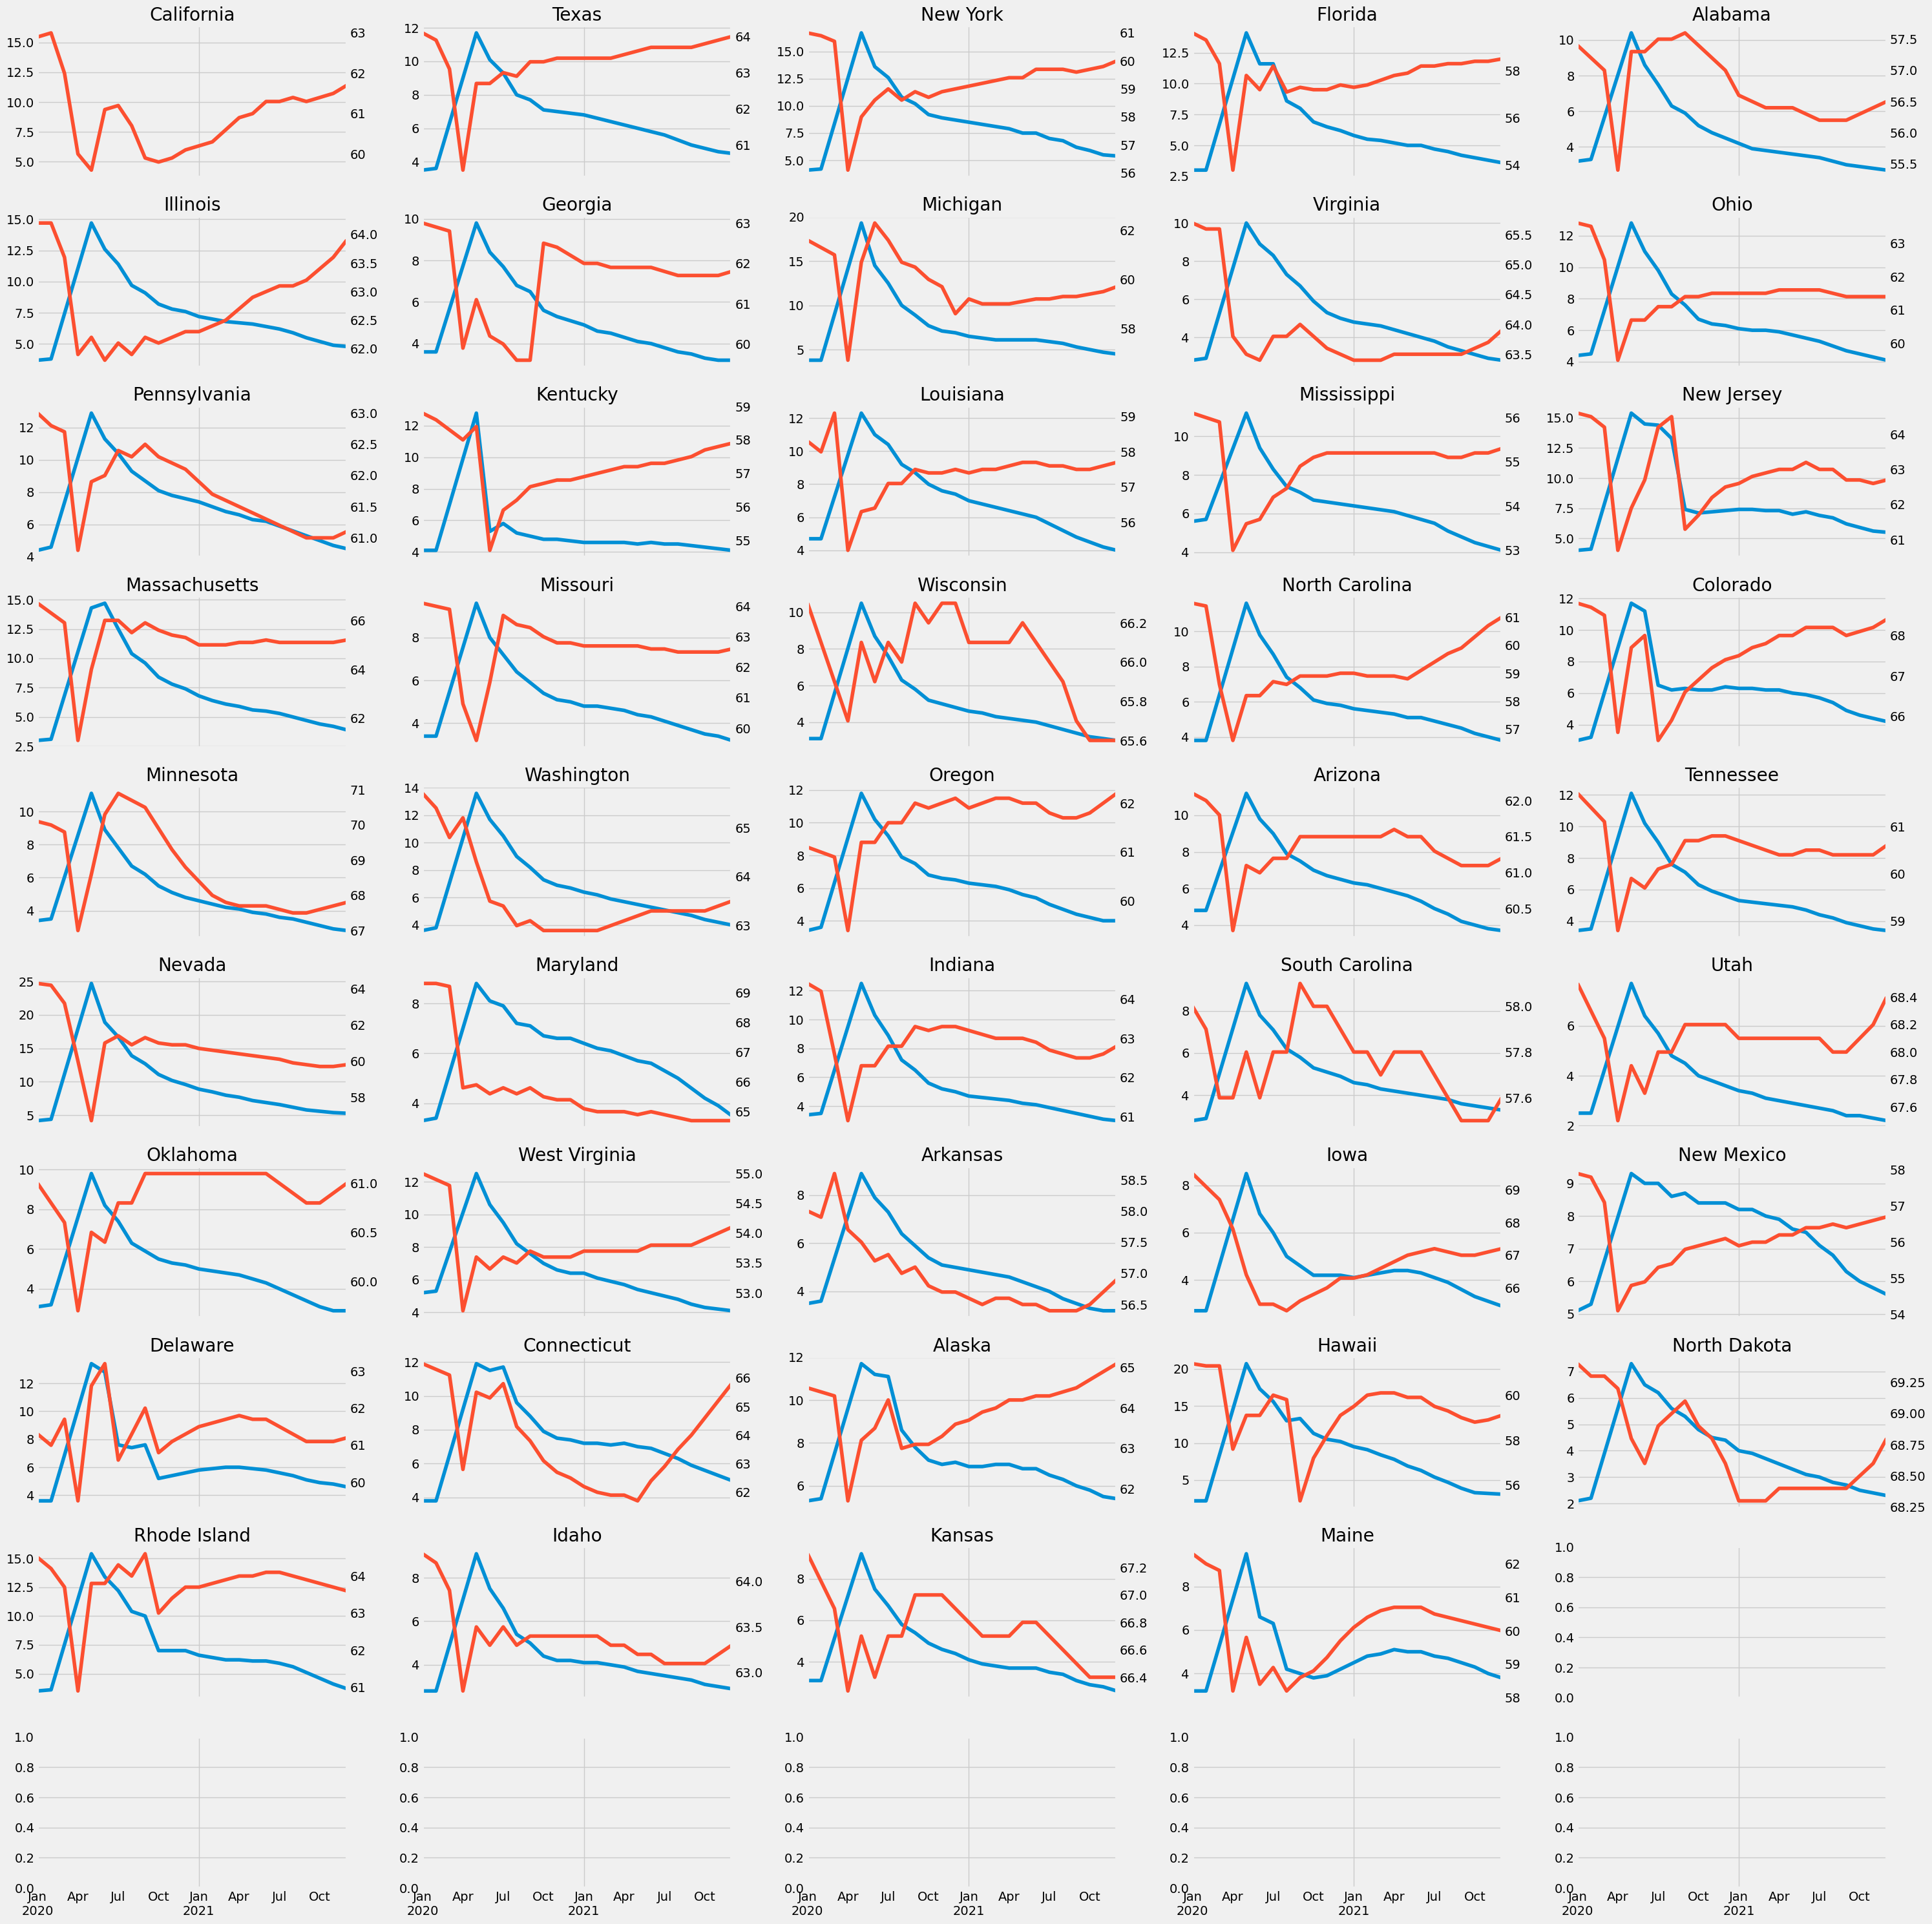

In [40]:
fig, axs = plt.subplots(10, 5, figsize=(30, 30), sharex=True)
axs = axs.flatten()

i = 0
for state in uemp_states.columns:
    if state in ["District Of Columbia","Puerto Rico"]:
        continue
    ax2 = axs[i].twinx()
    uemp_states.query('index >= 2020 and index < 2022')[state] \
        .plot(ax=axs[i], label='Unemployment')
    part_states.query('index >= 2020 and index < 2022')[state] \
        .plot(ax=ax2, label='Participation', color=color_pal[1])
    ax2.grid(False)
    axs[i].set_title(state)
    i += 1
plt.tight_layout()
plt.show()

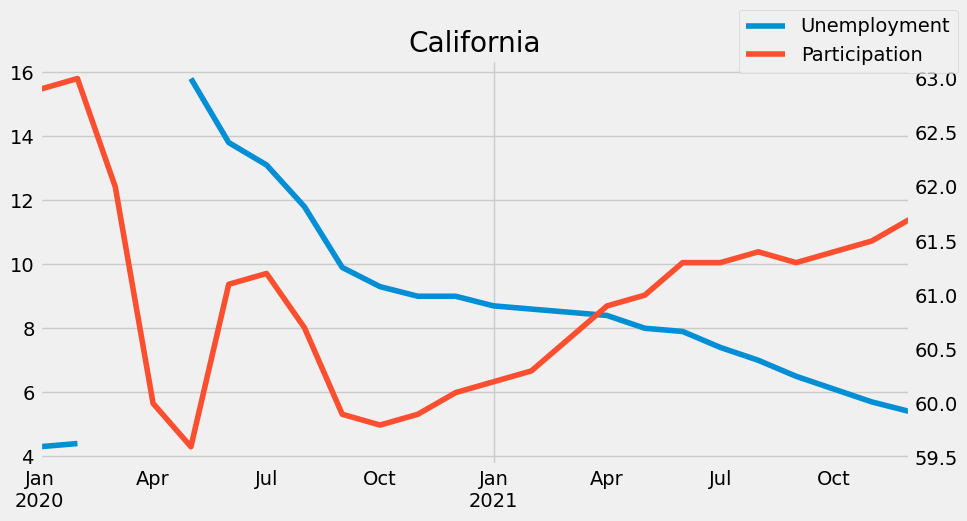

In [41]:
state = 'California'
fig, ax = plt.subplots(figsize=(10, 5), sharex=True)
ax2 = ax.twinx()
uemp_states2 = uemp_states.asfreq('MS')
l1 = uemp_states2.query('index >= 2020 and index < 2022')[state] \
    .plot(ax=ax, label='Unemployment')
l2 = part_states.dropna().query('index >= 2020 and index < 2022')[state] \
    .plot(ax=ax2, label='Participation', color=color_pal[1])
ax2.grid(False)
ax.set_title(state)
fig.legend(labels=['Unemployment','Participation'])
plt.show()